# Baselines, runs, and blends: apples-to-apples comparison

This notebook combines every pooled baseline, evaluated LOSO run, and CV-selected blend on the same 1,188 post-2016 test samples at five unseen stations.

Primary files:

- `output/baselines/test_metrics.json`
- `output/baselines/model_metrics.json`
- `output/baselines/test_metrics_by_station.json`
- `output/baselines/test_predictions.npz`
- `output/baselines/model_predictions.npz`
- `output/blends/*/selection.json`, `oof_weight_grid.csv`, and predictions


In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
PACKAGE_DIR = Path.cwd()
if not (PACKAGE_DIR / 'config.py').exists():
    if (PACKAGE_DIR / 'LAND_AS').exists():
        PACKAGE_DIR = PACKAGE_DIR / 'LAND_AS'
    elif (PACKAGE_DIR.parent / 'config.py').exists():
        PACKAGE_DIR = PACKAGE_DIR.parent
REPO_ROOT = PACKAGE_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from LAND_AS.metrics import regression_metrics, extreme_metrics

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 160, 'font.size': 9})
FIG_DIR = PACKAGE_DIR / 'output' / 'figures' / 'comparison'
FIG_DIR.mkdir(parents=True, exist_ok=True)
BASE_DIR = PACKAGE_DIR / 'output' / 'baselines'
BLEND_DIR = PACKAGE_DIR / 'output' / 'blends'
baseline_metrics = json.loads((BASE_DIR / 'test_metrics.json').read_text())
model_metrics = json.loads((BASE_DIR / 'model_metrics.json').read_text())
by_station = json.loads((BASE_DIR / 'test_metrics_by_station.json').read_text())
baseline_pred = np.load(BASE_DIR / 'test_predictions.npz', allow_pickle=True)
model_pred = np.load(BASE_DIR / 'model_predictions.npz', allow_pickle=True)
print('Baselines:', list(baseline_metrics))
print('Runs/blends:', list(model_metrics))


Baselines: ['pooled_mean', 'month_climatology', 'persistence', 'ridge', 'tweedie_glm', 'gbm']
Runs/blends: ['weekly_land_v5', 'weekly_land_v5_huber', 'weekly_land_v5_huber_rw', 'weekly_land_v5_huber_rw_msemon', 'v5_gamma_huber_cv_mse', 'v5_gamma_huber_rw_cv_mse', 'v5_gamma_huber_rw_msemon_cv_mse']


,kind,rmse,mae,bias,r2,spearman_r,pctl_pred_mm,pctl_rel_bias,csi_50mm
ridge,baseline,49.353321,35.901507,1.020925,0.479733,0.683361,207.090488,-0.223151,0.646383
v5_gamma_huber_cv_mse,blend,50.363238,35.00844,-4.725839,0.458222,0.667158,197.532954,-0.259004,0.641604
gbm,baseline,50.364538,34.293222,-6.640962,0.458194,0.670921,203.97464,-0.23484,0.631841
weekly_land_v5_huber_rw_msemon,run,50.372949,35.748804,0.827309,0.458013,0.666856,202.054979,-0.242041,0.63164
v5_gamma_huber_rw_msemon_cv_mse,blend,50.435939,35.736944,0.22893,0.456657,0.66614,202.5445,-0.240205,0.635183
v5_gamma_huber_rw_cv_mse,blend,50.488489,35.709715,-0.174838,0.455524,0.665476,202.285936,-0.241175,0.63658
weekly_land_v5_huber_rw,run,50.49535,35.561312,-0.653439,0.455376,0.666402,202.19815,-0.241504,0.631887
weekly_land_v5_huber,run,50.746408,34.969974,-6.927083,0.449947,0.664076,198.463278,-0.255514,0.63555
weekly_land_v5,run,50.843011,36.038715,-0.004925,0.447851,0.661612,206.142452,-0.226708,0.642599
tweedie_glm,baseline,55.32191,35.528162,-12.043644,0.346285,0.72408,226.788412,-0.14926,0.660105


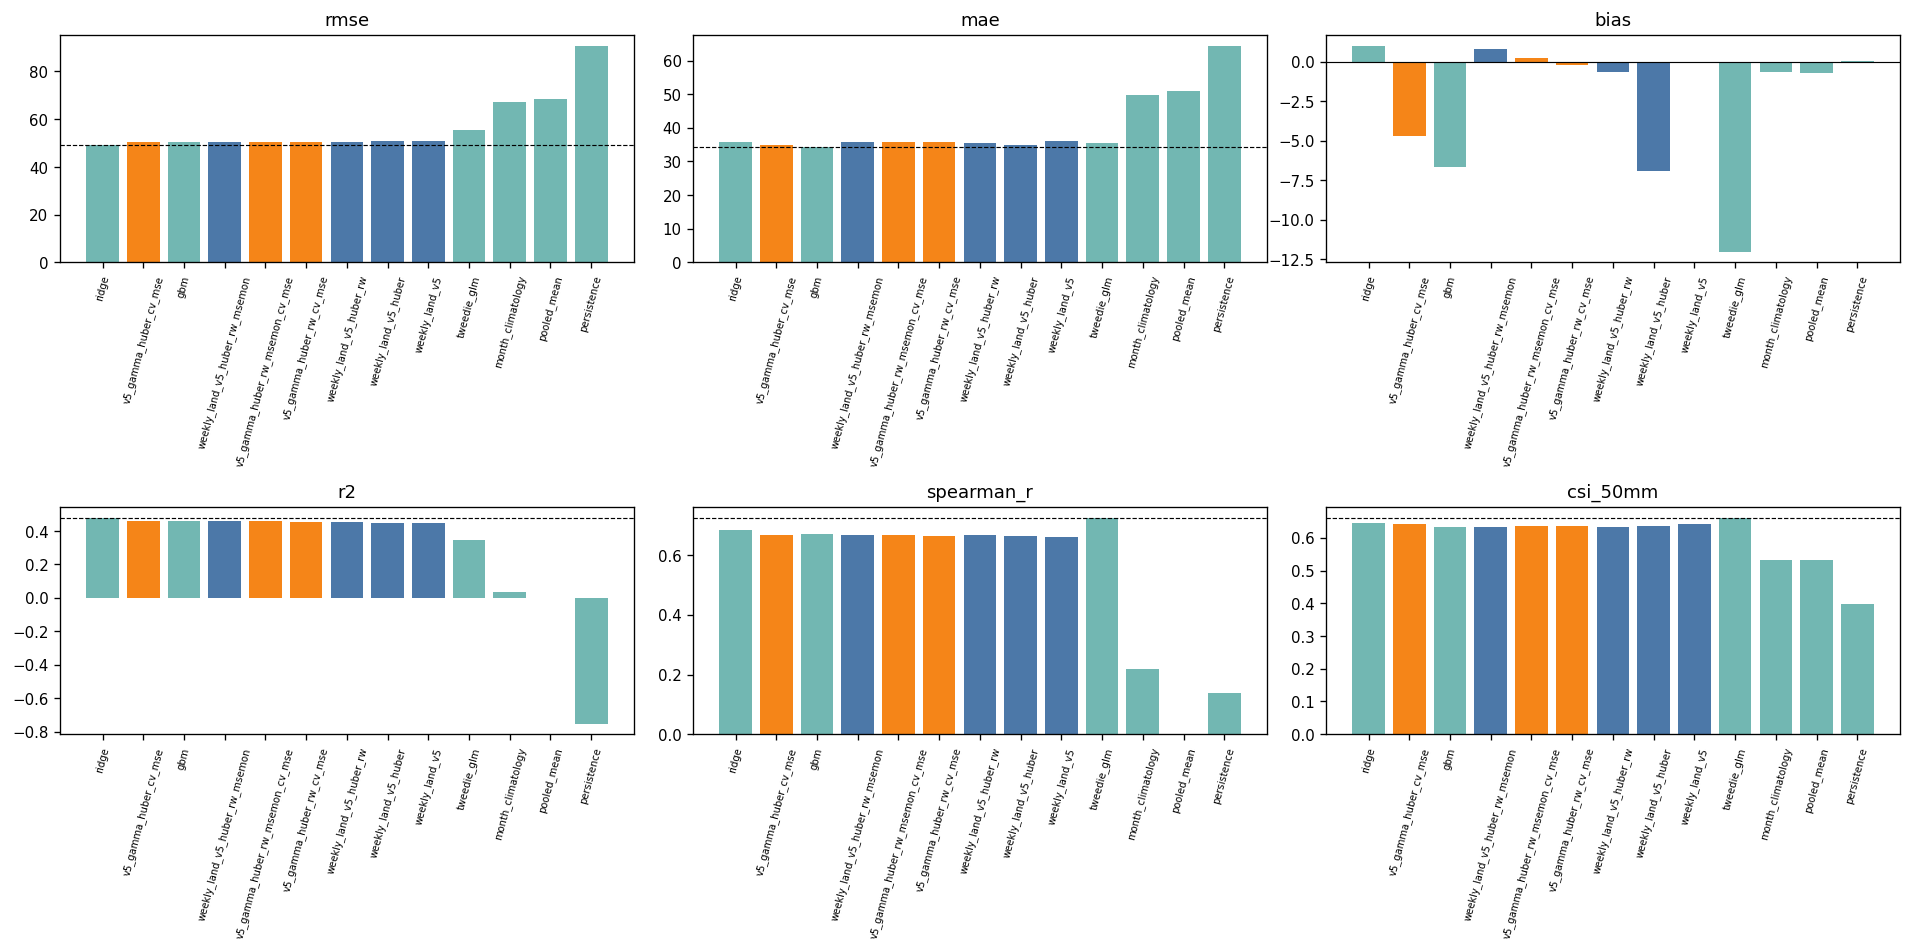

In [2]:
all_metrics = {}
for name, metrics in baseline_metrics.items():
    all_metrics[name] = {'kind': 'baseline', **metrics}
all_metrics.update(model_metrics)
metrics_df = pd.DataFrame(all_metrics).T
order = metrics_df.sort_values('rmse').index
cols = ['kind', 'rmse', 'mae', 'bias', 'r2', 'spearman_r', 'pctl_pred_mm', 'pctl_rel_bias', 'csi_50mm']
display(metrics_df.loc[order, cols].round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, metric in zip(axes.ravel(), ['rmse', 'mae', 'bias', 'r2', 'spearman_r', 'csi_50mm']):
    vals = metrics_df.loc[order, metric]
    colors = ['#72b7b2' if metrics_df.loc[n, 'kind'] == 'baseline' else '#4c78a8' if metrics_df.loc[n, 'kind'] == 'run' else '#f58518' for n in order]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=75, labelsize=6)
    if metric in ['rmse', 'mae', 'r2', 'spearman_r', 'csi_50mm']:
        ax.axhline(vals.max() if metric not in ['rmse', 'mae'] else vals.min(), color='k', ls='--', lw=0.7)
    else:
        ax.axhline(0, color='k', lw=0.7)
plt.tight_layout()
fig.savefig(FIG_DIR / 'overall_metric_comparison.svg', bbox_inches='tight')
plt.show()


## Per-station comparison

These heatmaps are the quickest way to see where each model differs. The neural models are not uniformly better than the pooled baselines; Ridge and GBM are competitive at several stations.


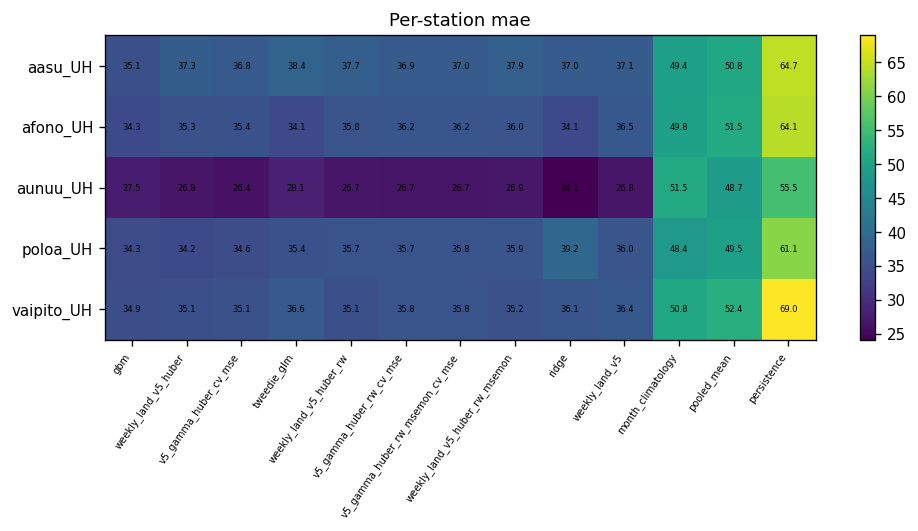

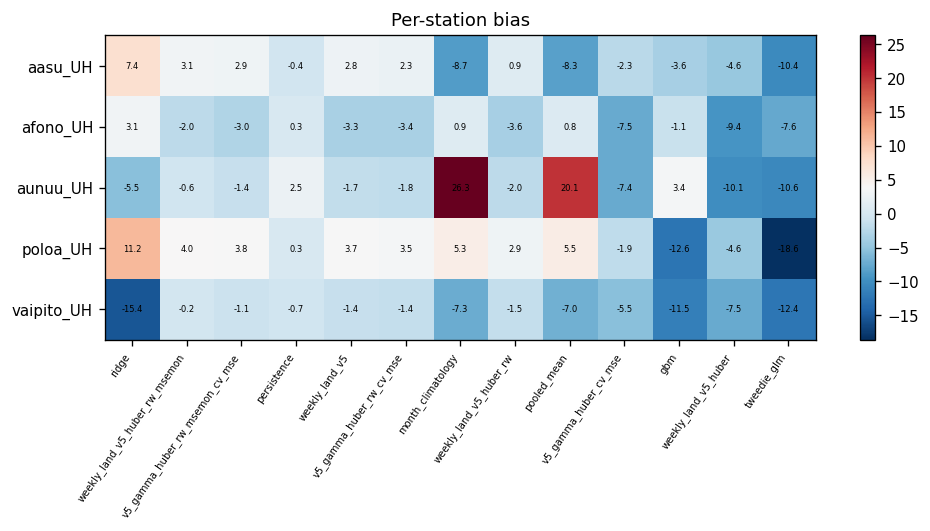

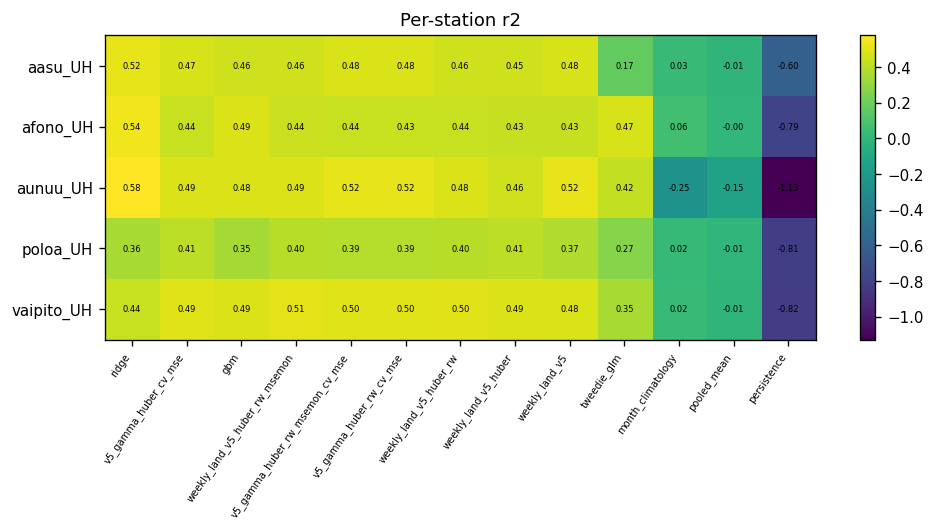

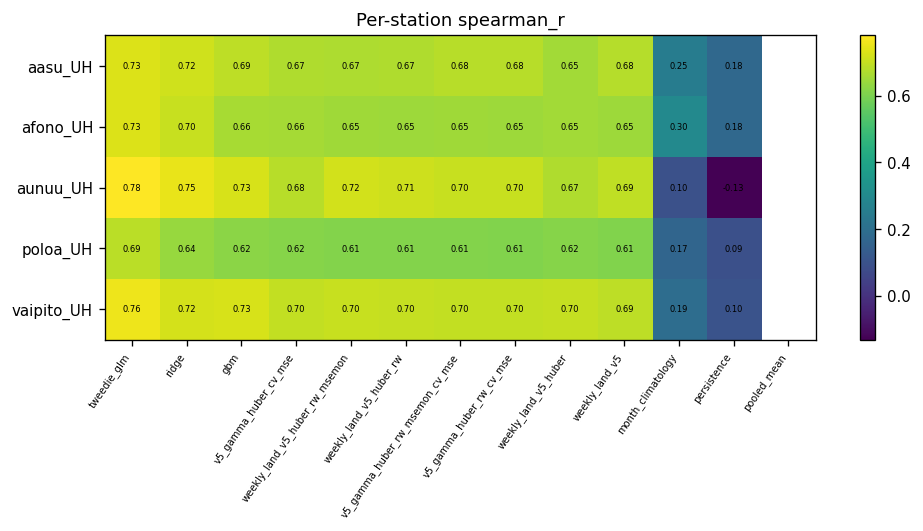

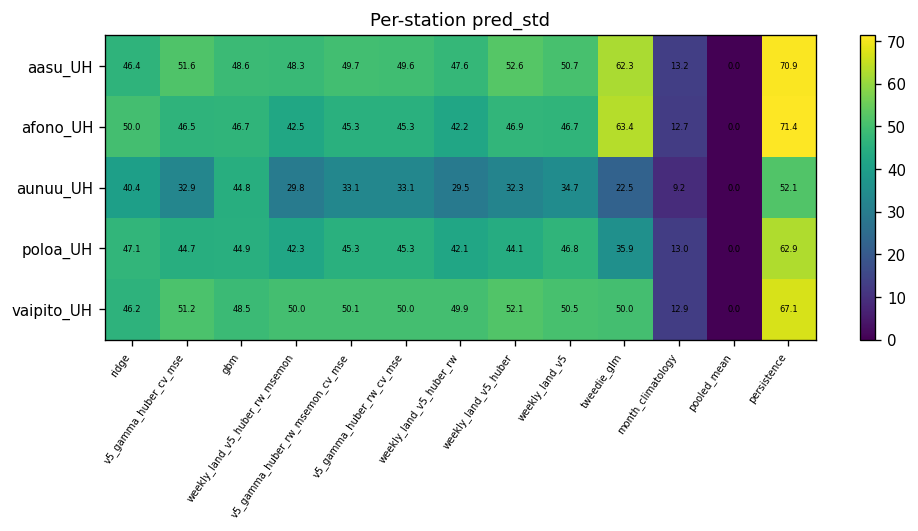

In [3]:
station_frames = {}
for metric in ['mae', 'rmse', 'bias', 'r2', 'spearman_r', 'obs_std', 'pred_std']:
    station_frames[metric] = pd.DataFrame({name: pd.Series(values) for name, values in by_station.items()}).applymap(
        lambda x: x.get(metric) if isinstance(x, dict) else np.nan
    )
for metric in ['mae', 'bias', 'r2', 'spearman_r', 'pred_std']:
    if metric in metrics_df.columns:
        order = metrics_df.sort_values(metric, ascending=(metric in ['mae'])).index
    else:
        order = metrics_df.sort_values('rmse').index
    pivot = station_frames[metric].loc[:, order]
    fig, ax = plt.subplots(figsize=(max(8, 0.65*len(pivot.columns)), 4.5))
    cmap = 'RdBu_r' if metric == 'bias' else 'viridis'
    im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
    ax.set_xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=55, ha='right', fontsize=6)
    ax.set_yticks(np.arange(len(pivot.index)), pivot.index)
    ax.set_title(f'Per-station {metric}')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            if np.isfinite(pivot.iloc[i, j]):
                ax.text(j, i, f'{pivot.iloc[i, j]:.2f}' if metric in ['r2', 'spearman_r'] else f'{pivot.iloc[i, j]:.1f}', ha='center', va='center', fontsize=5)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'station_{metric}_heatmap.svg', bbox_inches='tight')
    plt.show()

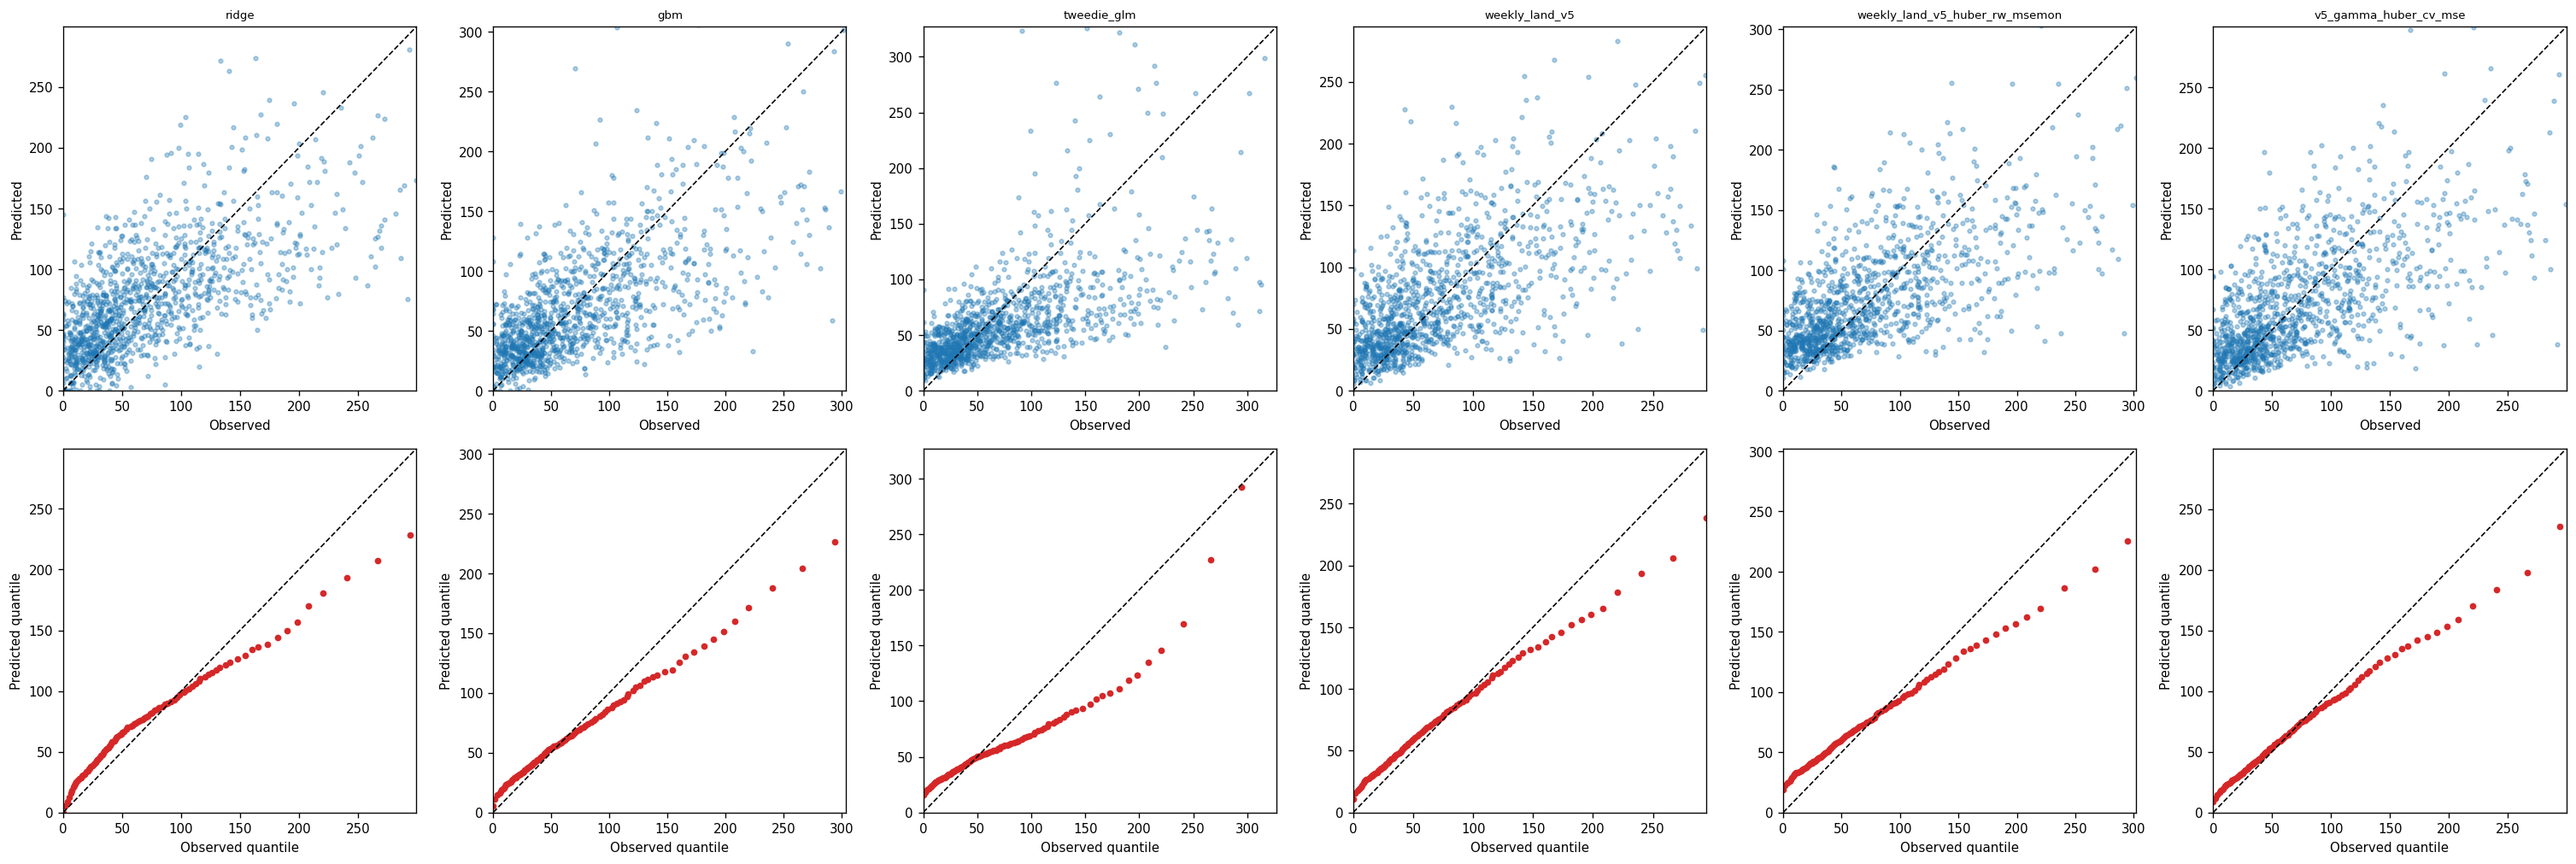

In [4]:
preds = {k.replace('pred_', ''): baseline_pred[k] for k in baseline_pred.files if k.startswith('pred_')}
preds.update({k.replace('pred_', ''): model_pred[k] for k in model_pred.files if k.startswith('pred_')})
observed = baseline_pred['observed']
stations = baseline_pred['stations'].astype(str)
selected = ['ridge', 'gbm', 'tweedie_glm', 'weekly_land_v5', 'weekly_land_v5_huber_rw_msemon', 'v5_gamma_huber_cv_mse']
selected = [s for s in selected if s in preds]
fig, axes = plt.subplots(2, len(selected), figsize=(4.2*len(selected), 8.5), squeeze=False)
for j, name in enumerate(selected):
    pred = preds[name]
    lim = np.percentile(np.r_[observed, pred], 99.5)
    axes[0, j].scatter(observed, pred, s=8, alpha=0.35)
    axes[0, j].plot([0, lim], [0, lim], 'k--', lw=1)
    axes[0, j].set_title(name, fontsize=8)
    axes[0, j].set_xlim(0, lim); axes[0, j].set_ylim(0, lim)
    axes[0, j].set_xlabel('Observed')
    axes[0, j].set_ylabel('Predicted')
    qs = np.linspace(0.01, 0.99, 99)
    axes[1, j].scatter(np.quantile(observed, qs), np.quantile(pred, qs), s=13, color='#d62728')
    axes[1, j].plot([0, lim], [0, lim], 'k--', lw=1)
    axes[1, j].set_xlim(0, lim); axes[1, j].set_ylim(0, lim)
    axes[1, j].set_xlabel('Observed quantile')
    axes[1, j].set_ylabel('Predicted quantile')
plt.tight_layout()
fig.savefig(FIG_DIR / 'selected_scatter_qq.svg', bbox_inches='tight')
plt.show()


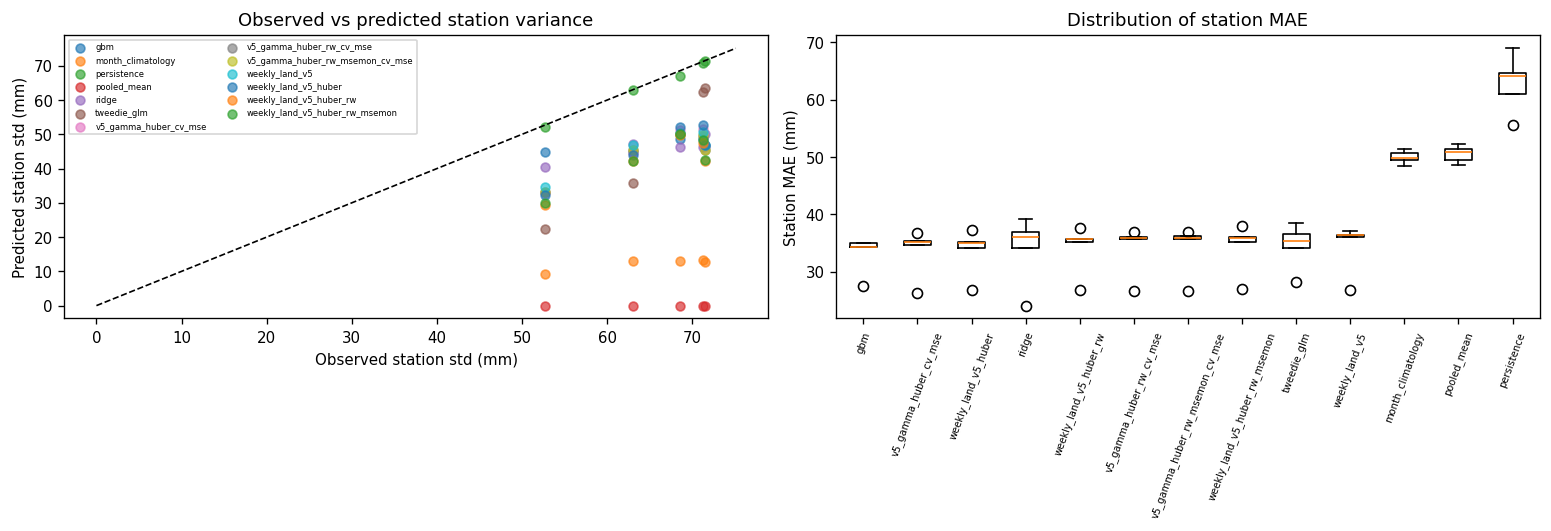

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
disp = []
for name, pred in preds.items():
    for station in sorted(set(stations)):
        mask = stations == station
        disp.append({'model': name, 'station': station, 'obs_std': observed[mask].std(), 'pred_std': pred[mask].std(), 'mae': np.mean(np.abs(pred[mask]-observed[mask]))})
disp = pd.DataFrame(disp)
for name, group in disp.groupby('model'):
    axes[0].scatter(group['obs_std'], group['pred_std'], s=28, alpha=0.65, label=name)
lim = max(disp['obs_std'].max(), disp['pred_std'].max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', lw=1)
axes[0].set_title('Observed vs predicted station variance')
axes[0].set_xlabel('Observed station std (mm)')
axes[0].set_ylabel('Predicted station std (mm)')
axes[0].legend(fontsize=5, ncol=2)
rank = disp.groupby('model')['mae'].mean().sort_values().index
axes[1].boxplot([disp.loc[disp['model'] == name, 'mae'] for name in rank], labels=rank)
axes[1].set_title('Distribution of station MAE')
axes[1].tick_params(axis='x', rotation=70, labelsize=6)
axes[1].set_ylabel('Station MAE (mm)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'station_variance_and_mae.svg', bbox_inches='tight')
plt.show()


## Time-series behavior

The panels use chronological week order within each test station. This helps reveal whether a model fails mainly during isolated extreme weeks or has a persistent station-level offset.


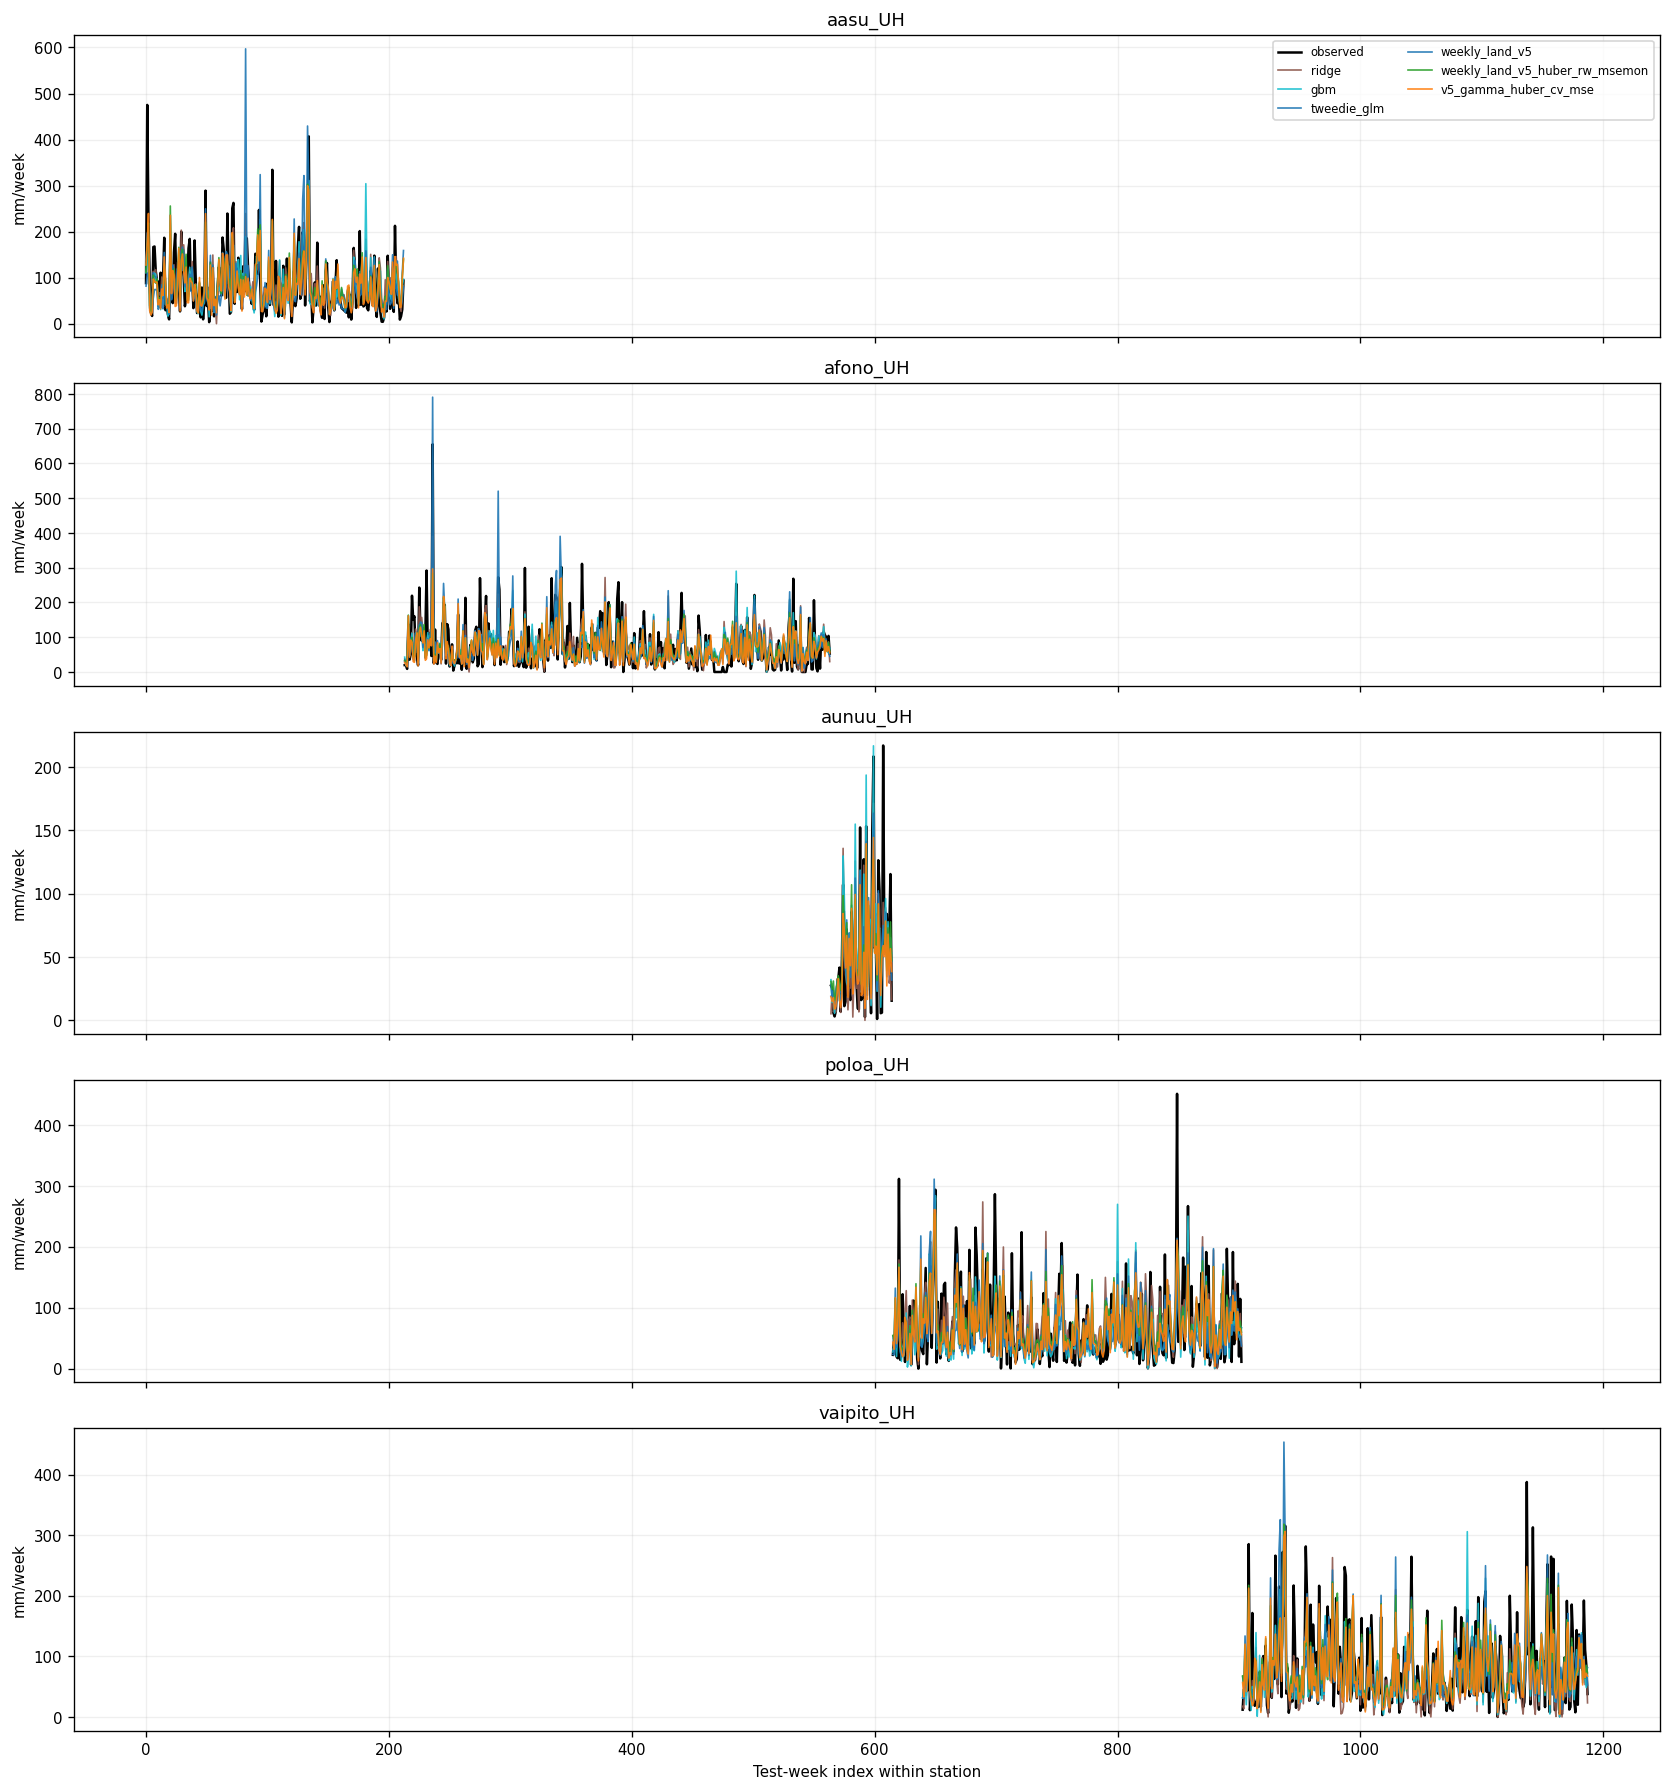

In [6]:
fig, axes = plt.subplots(len(set(stations)), 1, figsize=(14, 3*len(set(stations))), sharex=True)
colors = {'ridge': '#8c564b', 'gbm': '#17becf', 'weekly_land_v5': '#1f77b4', 'weekly_land_v5_huber_rw_msemon': '#2ca02c', 'v5_gamma_huber_cv_mse': '#ff7f0e'}
for ax, station in zip(axes, sorted(set(stations))):
    mask = stations == station
    ax.plot(np.where(mask)[0], observed[mask], color='k', lw=1.5, label='observed')
    for name in selected:
        ax.plot(np.where(mask)[0], preds[name][mask], lw=1.0, alpha=0.9, color=colors.get(name), label=name)
    ax.set_title(station)
    ax.set_ylabel('mm/week')
    ax.grid(alpha=0.2)
axes[0].legend(ncol=2, fontsize=7)
axes[-1].set_xlabel('Test-week index within station')
plt.tight_layout()
fig.savefig(FIG_DIR / 'selected_time_series.svg', bbox_inches='tight')
plt.show()


## Blend selection diagnostics

Blend weights are selected only on LOSO held-out predictions. Comparing the OOF curve to test metrics shows why a modest validation improvement may not transfer to the later test period.


,blend,huber_run,weight,oof_rmse,test_rmse,test_mae,test_bias
0,v5_gamma_huber_cv_mse,weekly_land_v5_huber,0.682,36.091944,50.363238,35.008440,-4.725839
1,v5_gamma_huber_rw_cv_mse,weekly_land_v5_huber_rw,0.262,37.246867,50.488489,35.709715,-0.174838
2,v5_gamma_huber_rw_msemon_cv_mse,weekly_land_v5_huber_rw_msemon,0.281,37.215157,50.435939,35.736944,0.228930


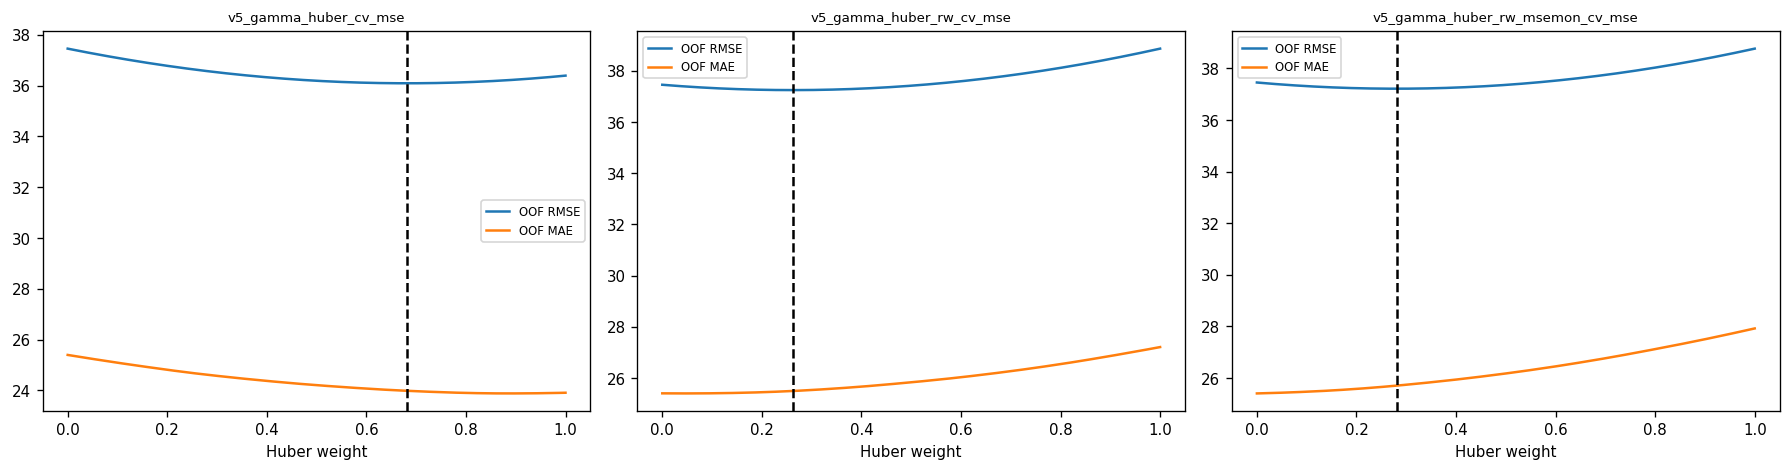

In [7]:
blend_dirs = sorted(p for p in BLEND_DIR.iterdir() if (p / 'selection.json').exists())
selection_rows = []
for path in blend_dirs:
    sel = json.loads((path / 'selection.json').read_text())
    test = json.loads((path / 'test_metrics.json').read_text())
    oof = json.loads((path / 'oof_metrics.json').read_text())
    selection_rows.append({'blend': path.name, 'huber_run': sel['huber_run'], 'weight': sel['selected_huber_weight'], 'oof_rmse': oof['rmse'], 'test_rmse': test['rmse'], 'test_mae': test['mae'], 'test_bias': test['bias']})
selection_df = pd.DataFrame(selection_rows)
display(selection_df)

fig, axes = plt.subplots(1, len(blend_dirs), figsize=(5*len(blend_dirs), 4), squeeze=False)
for ax, path in zip(axes.ravel(), blend_dirs):
    grid = pd.read_csv(path / 'oof_weight_grid.csv')
    sel = json.loads((path / 'selection.json').read_text())
    ax.plot(grid['huber_weight'], np.sqrt(grid['mse']), label='OOF RMSE')
    ax.plot(grid['huber_weight'], grid['mae'], label='OOF MAE')
    ax.axvline(sel['selected_huber_weight'], color='k', ls='--')
    ax.set_title(path.name, fontsize=8)
    ax.set_xlabel('Huber weight')
    ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIG_DIR / 'blend_weight_curves.svg', bbox_inches='tight')
plt.show()


,fold,station,mse,rmse,mae,bias,r2,spearman_r
8,8,iliili,1675.204487,40.929262,30.893913,-2.591506e-08,0.328799,0.489559
6,6,aunuu,2401.761697,49.007772,31.838580,-7.223095e-07,0.068897,0.308388
18,18,toa_ridge_WRCC,1803.025358,42.462046,31.983115,1.317133e-06,0.069399,0.259534
19,19,vaipito2000,2126.157839,46.110279,32.509405,-7.262534e-07,0.068526,0.214711
13,13,matatula,1794.852897,42.365704,34.531804,6.545867e-07,0.166832,0.388871
12,12,masefau,2134.356164,46.199093,35.987081,5.446068e-07,0.230159,0.453588
2,2,airport5101,2631.549178,51.298627,39.724120,1.660601e-07,0.092452,0.311483
7,7,fagaitua,3186.312982,56.447436,41.260506,4.836770e-07,0.093534,0.323504
3,3,airport80,3646.588654,60.386991,42.591821,1.376256e-06,0.107198,0.365489
14,14,mt_alava,3130.835486,55.953869,44.473772,1.117891e-06,0.124123,0.309253


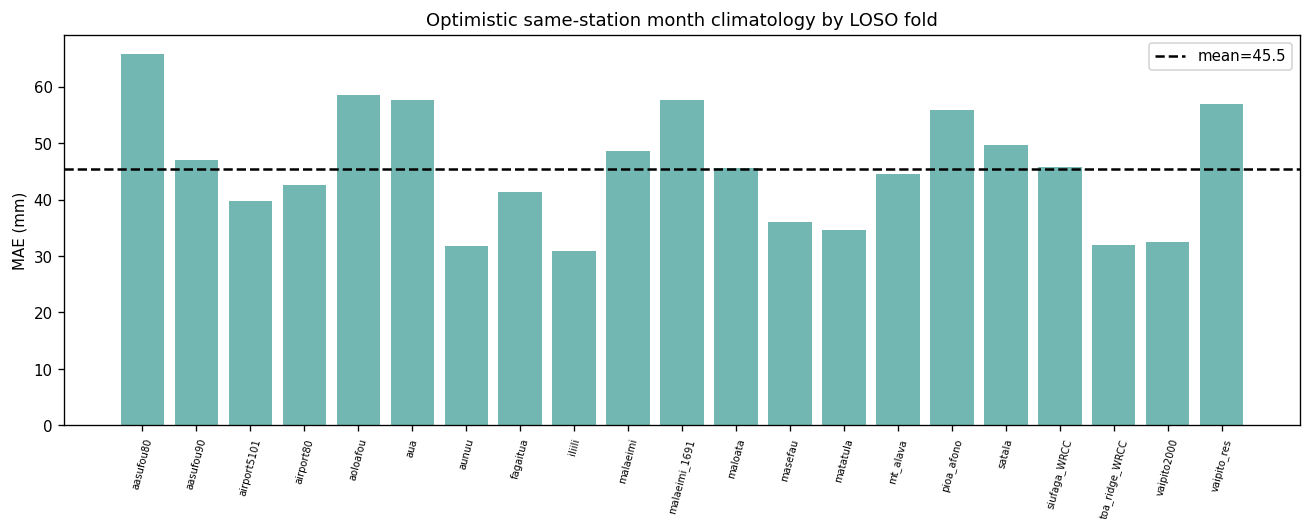

Saved figures: ['blend_weight_curves.svg', 'fold_station_climatology.svg', 'overall_metric_comparison.svg', 'selected_scatter_qq.svg', 'selected_time_series.svg', 'station_bias_heatmap.svg', 'station_mae_heatmap.svg', 'station_pred_std_heatmap.svg', 'station_r2_heatmap.svg', 'station_spearman_r_heatmap.svg', 'station_variance_and_mae.svg']


In [8]:
fold_metrics = pd.DataFrame(json.loads((BASE_DIR / 'fold_metrics.json').read_text()))
display(fold_metrics.sort_values('mae'))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(fold_metrics['station'], fold_metrics['mae'], color='#72b7b2')
ax.axhline(fold_metrics['mae'].mean(), color='k', ls='--', label=f"mean={fold_metrics['mae'].mean():.1f}")
ax.set_title('Optimistic same-station month climatology by LOSO fold')
ax.set_ylabel('MAE (mm)')
ax.tick_params(axis='x', rotation=75, labelsize=6)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / 'fold_station_climatology.svg', bbox_inches='tight')
plt.show()
print('Saved figures:', sorted(p.name for p in FIG_DIR.glob('*.svg')))
